In [31]:
from pathlib import Path

# Walk up from cwd to find project root (directory containing pyproject.toml)
def find_project_root(marker='pyproject.toml'):
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find {marker}, project root unknown')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'

In [32]:
import pandas as pd

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

# Basic shape
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (439140, 16)
Test: (188165, 15)


## Column

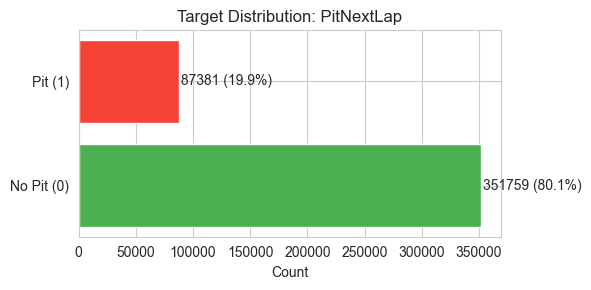

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Target distribution
fig, ax = plt.subplots(figsize=(6, 3))
counts = train["PitNextLap"].value_counts()
labels = ["No Pit (0)", "Pit (1)"]
values = counts.to_numpy()
ax.barh(labels, values, color=["#4CAF50", "#F44336"])
ax.set_title("Target Distribution: PitNextLap")
ax.set_xlabel("Count")
for i, v in enumerate(values):
    ax.text(v + 2000, i, f"{v} ({v/len(train):.1%})", va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [39]:
train['PitStop'].value_counts()

PitStop
0    379365
1     59775
Name: count, dtype: int64

In [47]:
train["TyreLife"].value_counts()

TyreLife
6.0     20663
4.0     20348
12.0    19945
3.0     18614
1.0     18440
        ...  
73.0       10
70.0        9
75.0        8
77.0        3
60.5        1
Name: count, Length: 78, dtype: int64

In [41]:
train["LapNumber"].value_counts()  # .to_dict()

LapNumber
1     16558
3     13988
6     13859
4     13641
12    13641
      ...  
73       54
74       48
75       35
77       14
78        2
Name: count, Length: 78, dtype: int64

In [51]:
train["LapTime (s)"].value_counts()

LapTime (s)
83.939     256
84.924     248
84.813     231
82.938     225
84.845     215
          ... 
121.959      1
87.803       1
72.202       1
111.110      1
88.968       1
Name: count, Length: 37719, dtype: int64

In [52]:
train["LapTime_Delta"].value_counts()

LapTime_Delta
 0.000     21473
-0.092      1183
-0.098      1042
-0.077       992
-0.074       876
           ...  
 12.161        1
-3.623         1
-9.024         1
-19.384        1
-69.695        1
Name: count, Length: 57552, dtype: int64

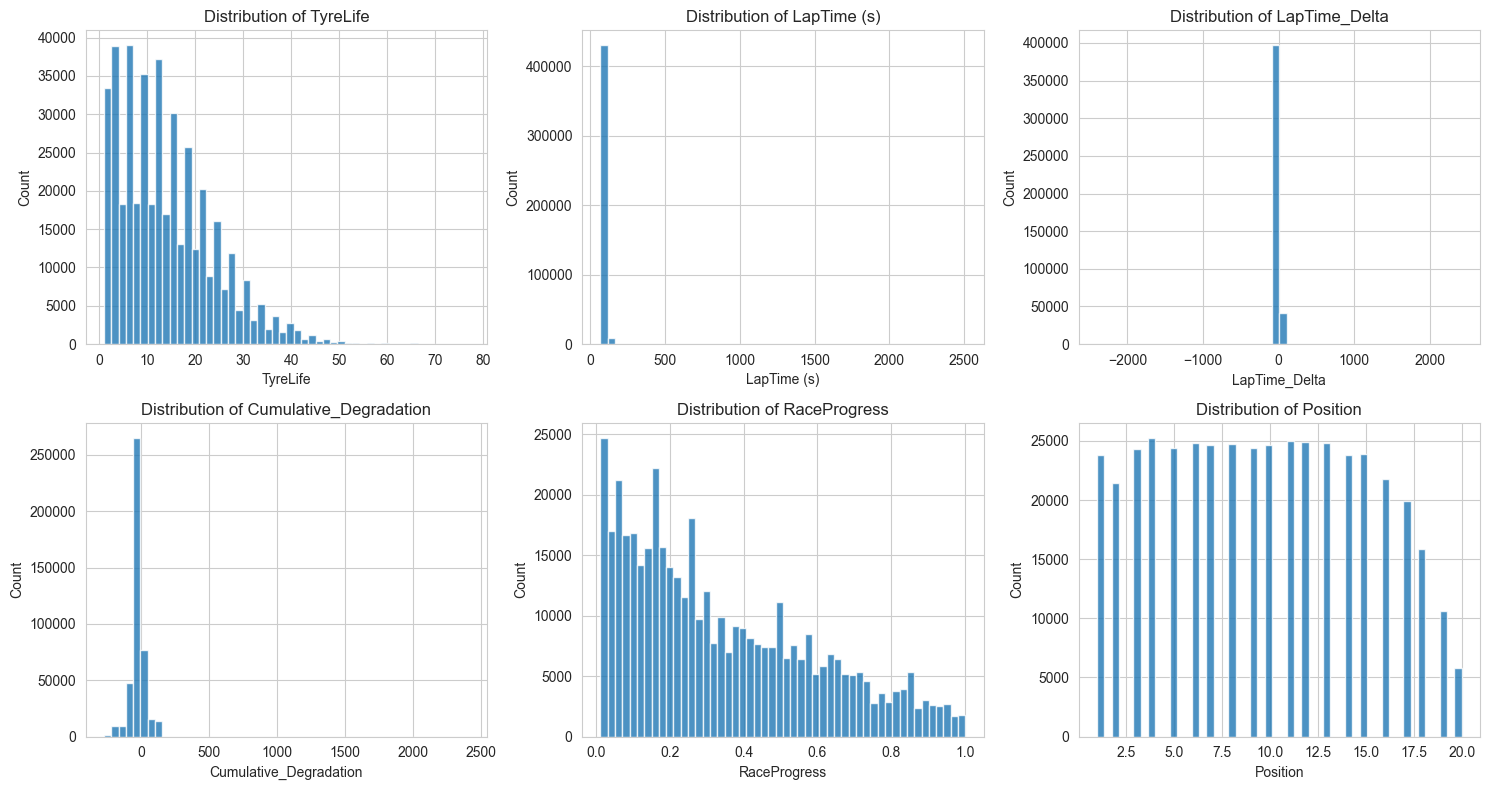

In [43]:
# 2. Numeric feature distributions
numeric_cols = ["TyreLife", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(train[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [57]:
len(train['Driver'].unique())

887

In [33]:
train["Driver"].value_counts()

Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D711       1
D755       1
D731       1
D716       1
D714       1
Name: count, Length: 887, dtype: int64

In [40]:
train["Stint"].value_counts()

Stint
1    216288
2    129536
3     69238
4     18903
5      4281
6       728
7       116
8        50
Name: count, dtype: int64

In [48]:
train["Year"].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [50]:
train["Race"].value_counts()

Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand Prix           15383
Qatar Grand Prix             13817
Japanese Grand Prix          12891
Las Vegas Grand Prix         12479
Azerbaijan Grand Prix        12126
São Paulo Grand Prix         11497
Belgian Grand Prix            9002
Chinese Grand Prix            7311
French Grand Prix             3185
Name: count, dtype: int64

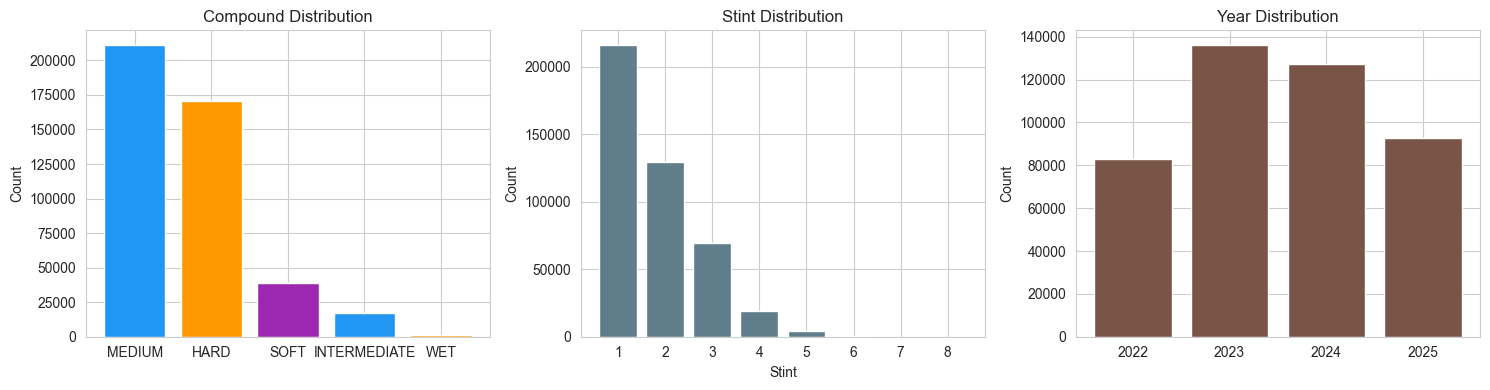

In [44]:
# 3. Categorical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compound
compound_counts = train["Compound"].value_counts()
axes[0].bar(compound_counts.index, compound_counts.values, color=["#2196F3", "#FF9800", "#9C27B0"])
axes[0].set_title("Compound Distribution")
axes[0].set_ylabel("Count")

# Stint
stint_counts = train["Stint"].value_counts().sort_index()
axes[1].bar(stint_counts.index.astype(str), stint_counts.values, color="#607D8B")
axes[1].set_title("Stint Distribution")
axes[1].set_xlabel("Stint")
axes[1].set_ylabel("Count")

# Year
year_counts = train["Year"].value_counts().sort_index()
axes[2].bar(year_counts.index.astype(str), year_counts.values, color="#795548")
axes[2].set_title("Year Distribution")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

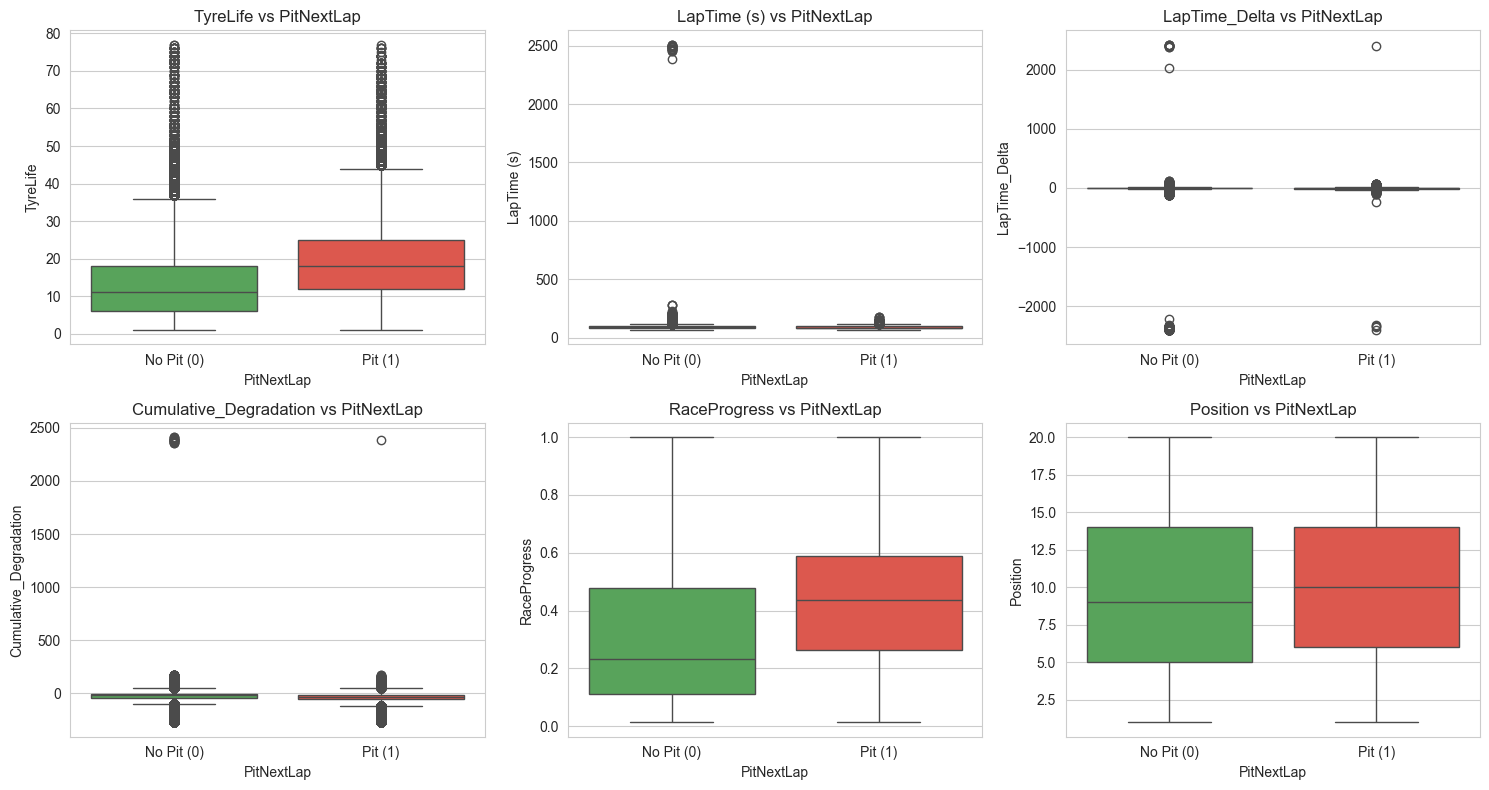

In [45]:
# 4. Numeric features vs Target (box plots)
numeric_features = ["TyreLife", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(x="PitNextLap", y=col, data=train, ax=ax,
                hue="PitNextLap", palette=["#4CAF50", "#F44336"], legend=False)
    ax.set_title(f"{col} vs PitNextLap")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Pit (0)", "Pit (1)"])
plt.tight_layout()
plt.show()

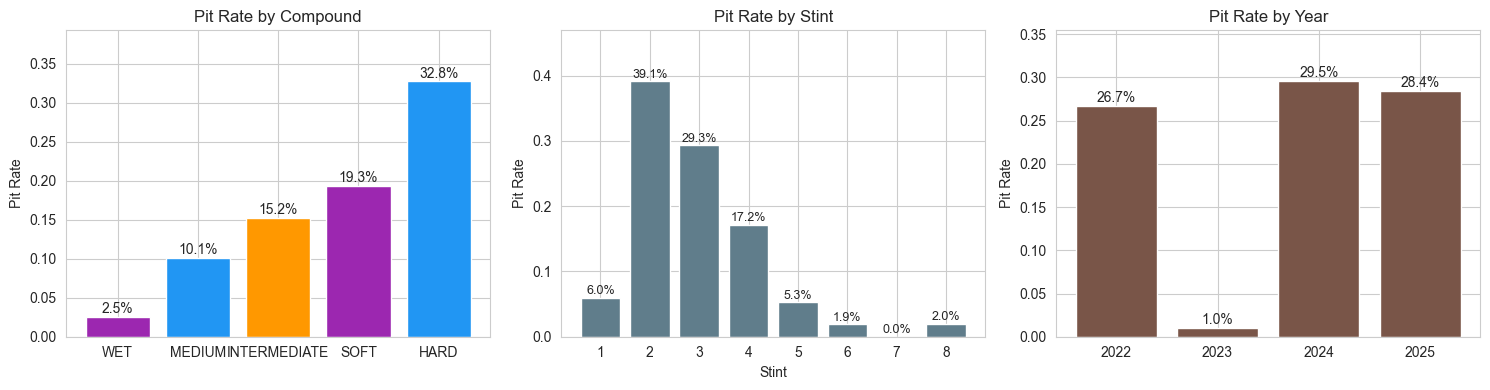

In [46]:
# 5. Categorical features vs Target (pit rate)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compound vs PitNextLap
compound_rate = train.groupby("Compound")["PitNextLap"].mean().sort_values()
axes[0].bar(compound_rate.index, compound_rate.values, color=["#9C27B0", "#2196F3", "#FF9800"])
axes[0].set_title("Pit Rate by Compound")
axes[0].set_ylabel("Pit Rate")
axes[0].set_ylim(0, compound_rate.max() * 1.2)
for i, v in enumerate(compound_rate.values):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

# Stint vs PitNextLap
stint_rate = train.groupby("Stint")["PitNextLap"].mean()
axes[1].bar(stint_rate.index.astype(str), stint_rate.values, color="#607D8B")
axes[1].set_title("Pit Rate by Stint")
axes[1].set_xlabel("Stint")
axes[1].set_ylabel("Pit Rate")
axes[1].set_ylim(0, stint_rate.max() * 1.2)
for i, v in enumerate(stint_rate.values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=9)

# Year vs PitNextLap
year_rate = train.groupby("Year")["PitNextLap"].mean()
axes[2].bar(year_rate.index.astype(str), year_rate.values, color="#795548")
axes[2].set_title("Pit Rate by Year")
axes[2].set_ylabel("Pit Rate")
axes[2].set_ylim(0, year_rate.max() * 1.2)
for i, v in enumerate(year_rate.values):
    axes[2].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

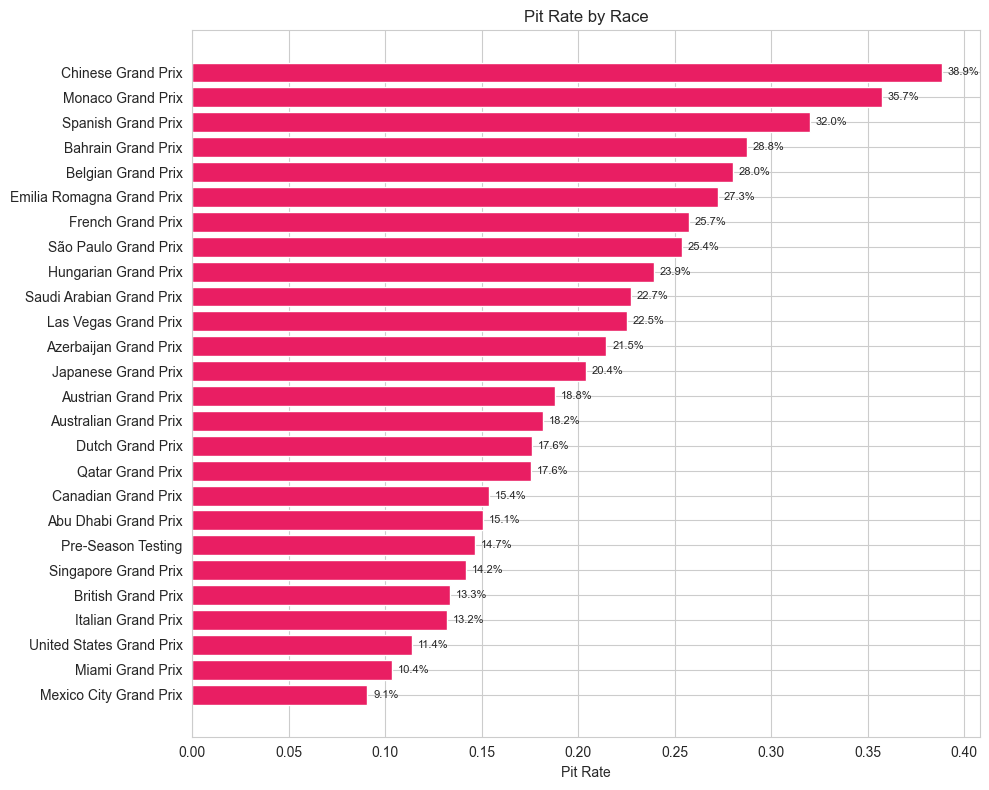

In [ ]:
# Pit rate by Race
race_rate = train.groupby("Race")["PitNextLap"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(race_rate.index, race_rate.to_numpy(), color="#E91E63")
ax.set_title("Pit Rate by Race")
ax.set_xlabel("Pit Rate")
for i, v in enumerate(race_rate.values):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

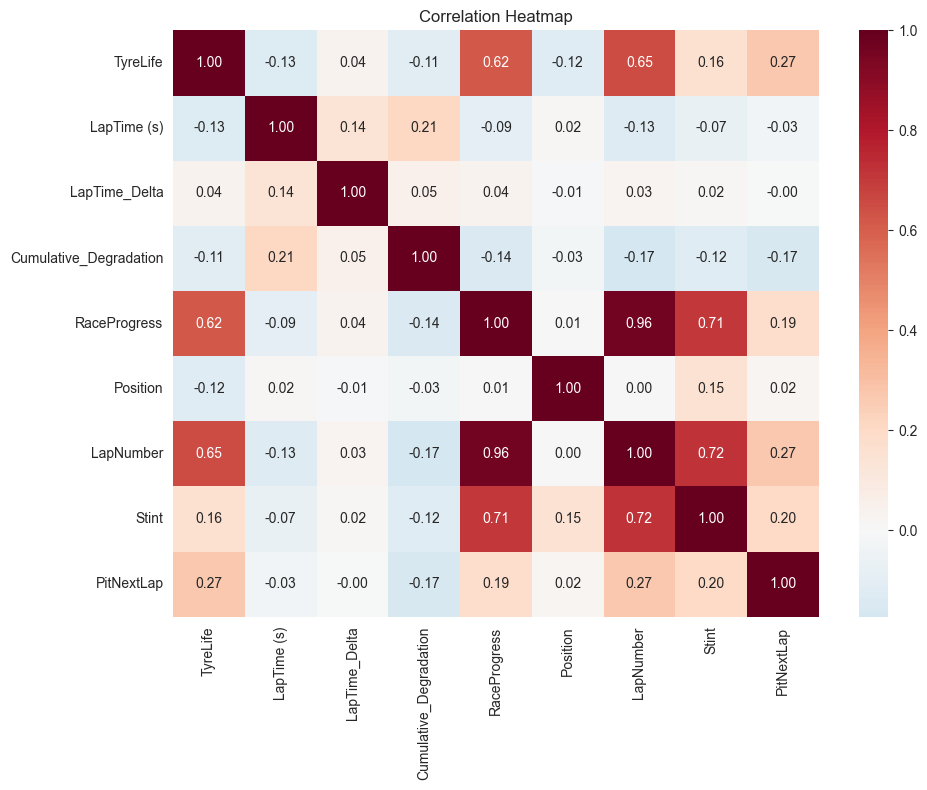

In [53]:
# 6. Correlation heatmap
numeric_cols = ["TyreLife", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
                "RaceProgress", "Position", "LapNumber", "Stint", "PitNextLap"]
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()